In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/Churn Modelling/Churn_Modelling.csv")

In [ ]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
data.shape

(10000, 14)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


<Axes: >

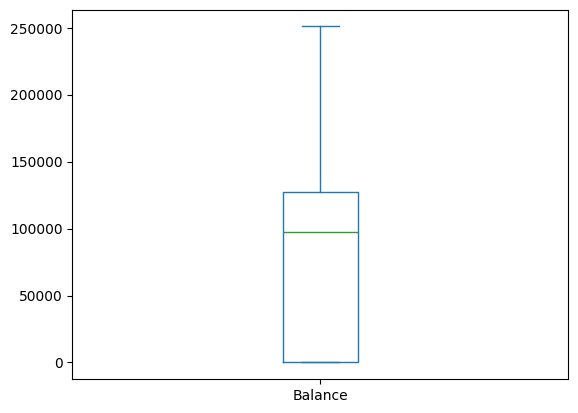

In [ ]:
df_cleaned['Balance'].plot(kind='box')

<Axes: >

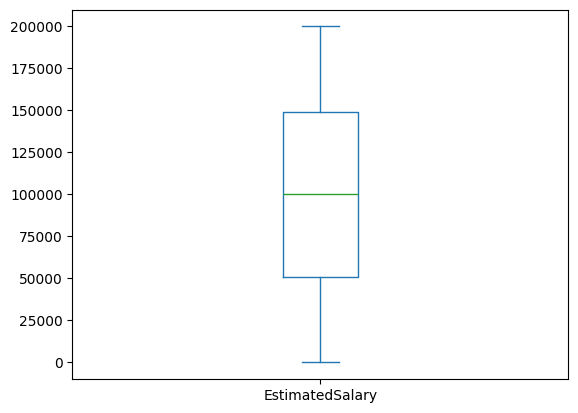

In [ ]:
data['EstimatedSalary'].plot(kind='box')

In [ ]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['Balance'].quantile(0.25)
Q3 = data['Balance'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define acceptable bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the dataframe to keep only values within bounds
df_cleaned = data[(data['Balance'] >= lower_bound) & (data['Balance'] <= upper_bound)]


<Axes: >

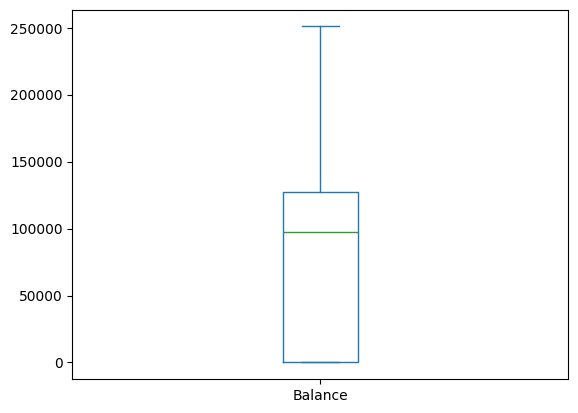

In [ ]:
df_cleaned['Balance'].plot(kind='box')

In [ ]:
df_cleaned.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['EstimatedSalary'].quantile(0.25)
Q3 = data['EstimatedSalary'].quantile(0.75)

# 2. Calculate the Interquartile Range
IQR = Q3 - Q1

# 3. Define acceptable bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the dataframe to keep only values within bounds
df_cleaned = data[(data['EstimatedSalary'] >= lower_bound) & (data['EstimatedSalary'] <= upper_bound)]


<Axes: >

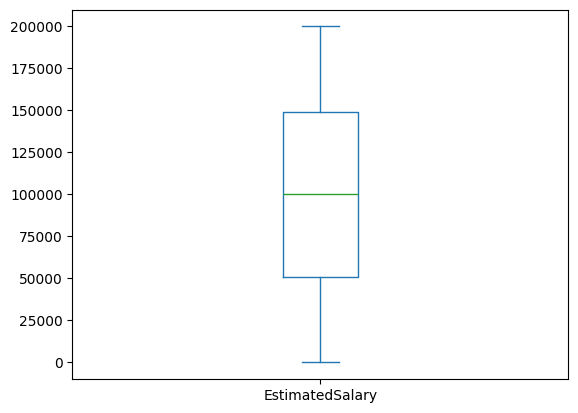

In [ ]:
df_cleaned['EstimatedSalary'].plot(kind='box')

In [ ]:
df_cleaned.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df_cleaned['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


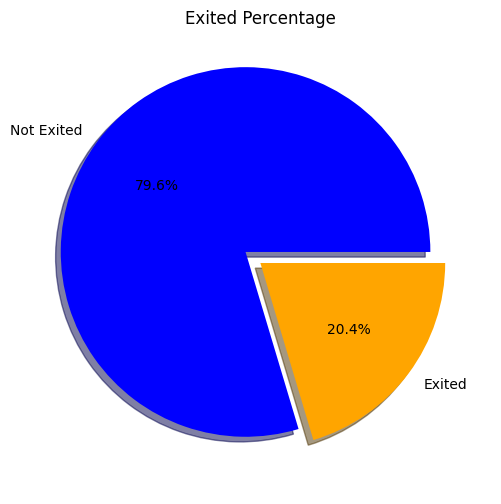

In [ ]:
exited_counts = df_cleaned['Exited'].value_counts()
explode = (0.1, 0) # Explode the 'Exited' slice slightly

plt.figure(figsize=(6,6))
plt.pie(exited_counts.values,
        explode=explode,
        colors=['blue','orange'], # Assign colors based on value_counts order (0 then 1)
        labels=['Not Exited','Exited'], # Provide meaningful labels
        autopct='%1.1f%%', # Formats values to show percentages
        shadow=True)
plt.title("Exited Percentage")
plt.show()

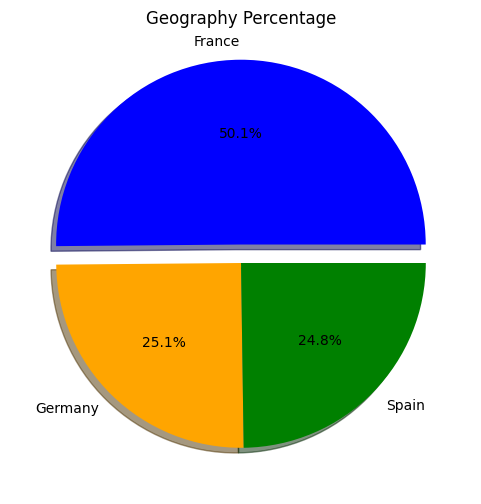

In [ ]:
exited_counts = df_cleaned['Geography'].value_counts()
# Adjust explode to match the number of unique geographies (3: France, Germany, Spain)
explode = (0.1, 0, 0) # Explode the first slice slightly

plt.figure(figsize=(6,6))
plt.pie(exited_counts.values,
        explode=explode,
        colors=['blue', 'orange', 'green'], # Assign colors for each geography
        labels=exited_counts.index, # Use the index of value_counts for labels
        autopct='%1.1f%%', # Formats values to show percentages
        shadow=True)
plt.title("Geography Percentage") # Update title
plt.show()

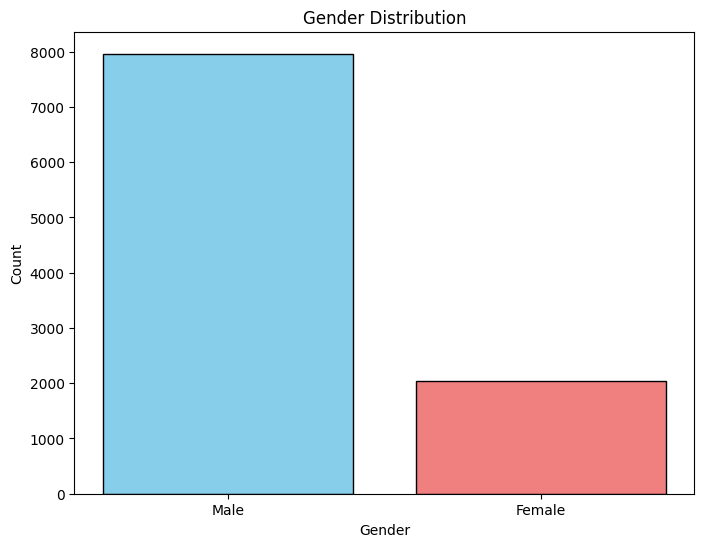

In [ ]:
gender_counts = df_cleaned['Gender'].value_counts()
exited_counts=df_cleaned['Exited'].value_counts()
# Create a bar chart
plt.figure(figsize=(8, 6))

plt.bar(gender_counts.index, exited_counts.values, color=['skyblue', 'lightcoral'], edgecolor='black')

# Add labels and title
plt.title('Gender Distribution')
plt.ylabel('Count')
plt.xlabel('Gender')
plt.show()

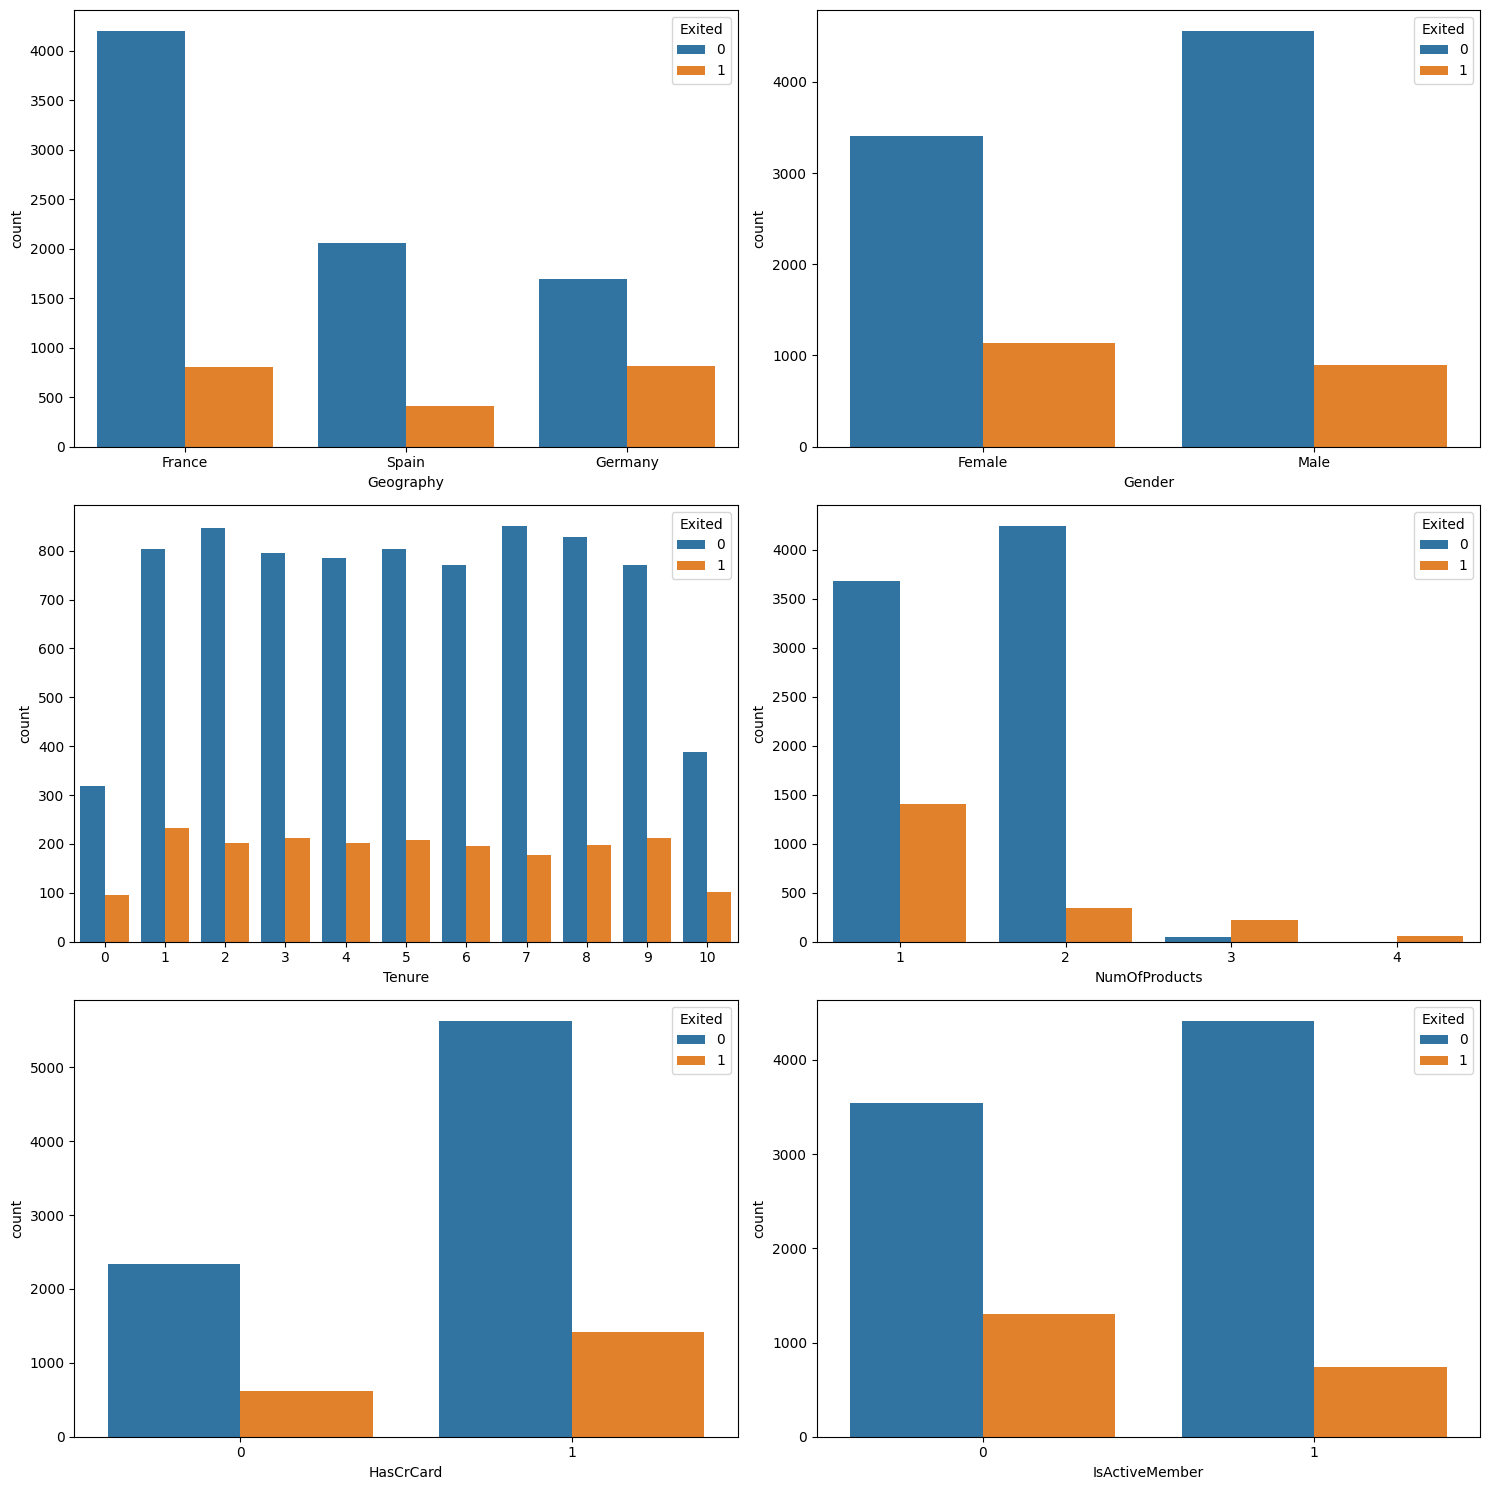

In [ ]:
fig,ax=plt.subplots(3,2,figsize=(15,15))

sns.countplot(x='Geography',hue='Exited',data=df_cleaned,ax=ax[0,0])
sns.countplot(x='Gender',hue='Exited',data=df_cleaned,ax=ax[0,1])
sns.countplot(x='Tenure',hue='Exited',data=df_cleaned,ax=ax[1,0])
sns.countplot(x='NumOfProducts', hue = 'Exited',data=df_cleaned,ax = ax[1][1])
sns.countplot(x='HasCrCard', hue = 'Exited',data=df_cleaned,ax = ax[2][0])
sns.countplot(x='IsActiveMember', hue = 'Exited', data=df_cleaned,ax = ax[2][1])

plt.tight_layout()
plt.show()

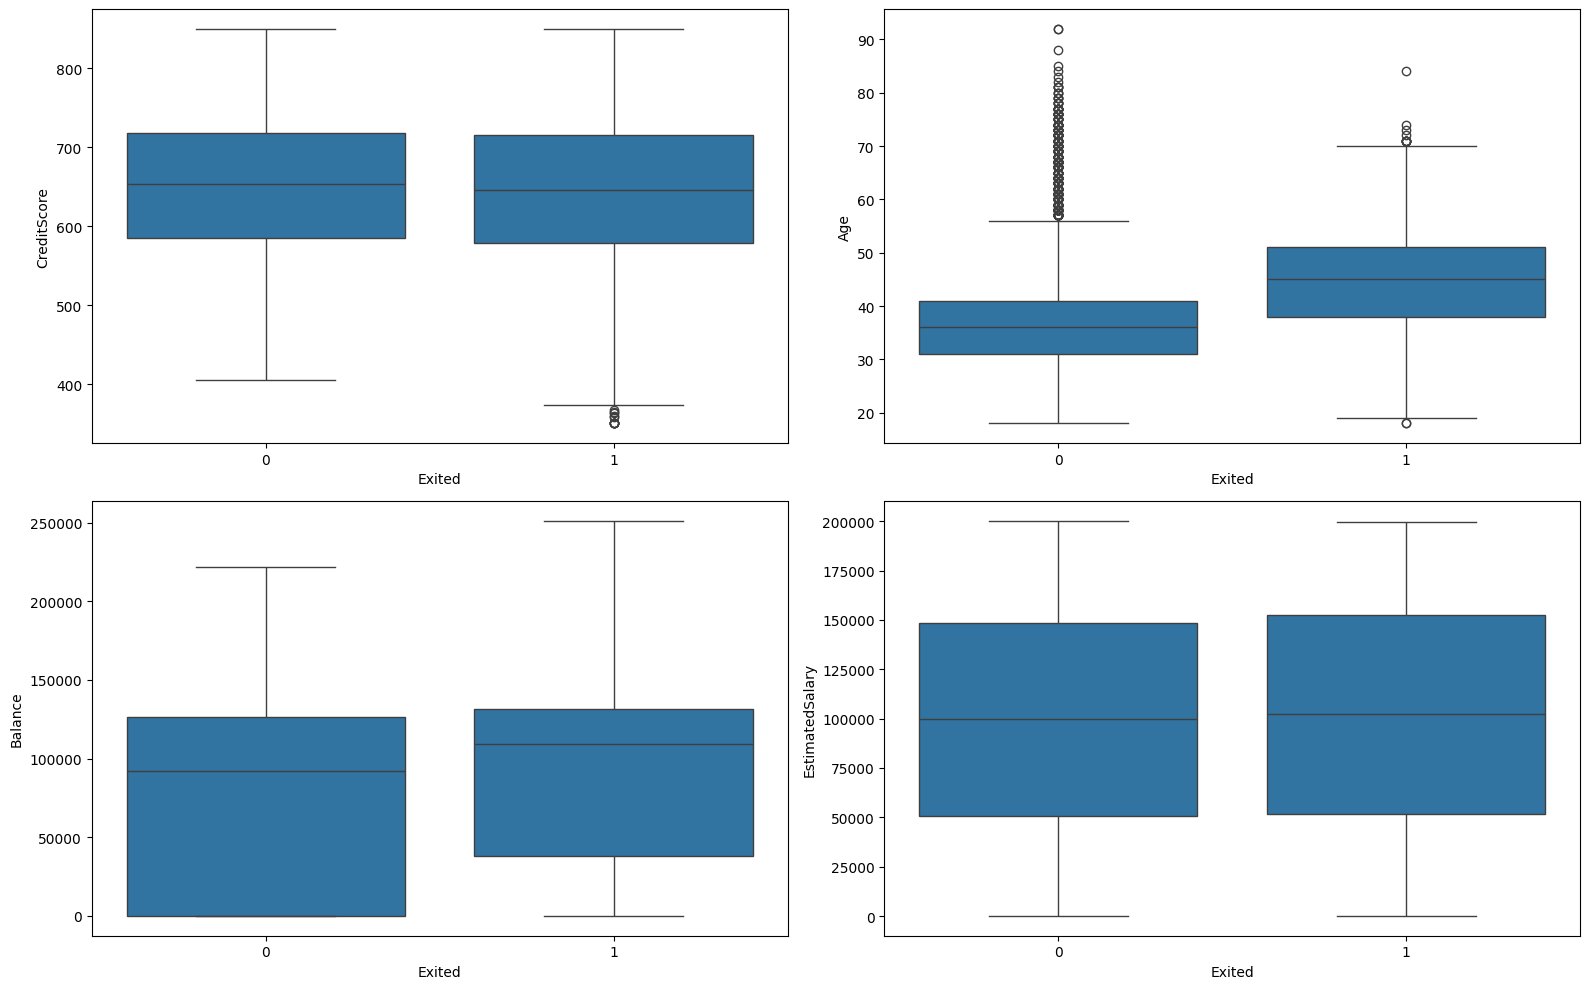

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (16, 10))

sns.boxplot(x = 'Exited', y = 'CreditScore', data = df_cleaned, ax = ax[0][0])
sns.boxplot(x = 'Exited', y = 'Age', data = df_cleaned, ax = ax[0][1])
sns.boxplot(x = 'Exited', y = 'Balance', data = df_cleaned, ax = ax[1][0])
sns.boxplot(x = 'Exited', y = 'EstimatedSalary', data = df_cleaned, ax = ax[1][1])

plt.tight_layout()
plt.show()

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CreditScore      10000 non-null  int64
 1   Geography        10000 non-null  int64
 2   Gender           10000 non-null  int64
 3   Age              10000 non-null  int64
 4   Tenure           10000 non-null  int64
 5   Balance          10000 non-null  int64
 6   NumOfProducts    10000 non-null  int64
 7   HasCrCard        10000 non-null  int64
 8   IsActiveMember   10000 non-null  int64
 9   EstimatedSalary  10000 non-null  int64
 10  Exited           10000 non-null  int64
dtypes: int64(11)
memory usage: 859.5 KB


In [ ]:
df_cleaned.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [ ]:
df_cleaned['Geography']=df_cleaned['Geography'].map({'France':0,'Germany':1,'Spain':2})
df_cleaned['Gender']=df_cleaned['Gender'].map({'Female':0,'Male':1})

In [ ]:
df_cleaned['Balance']=df_cleaned['Balance'].astype(np.int64)
df_cleaned['EstimatedSalary']=df_cleaned['EstimatedSalary'].astype(np.int64)

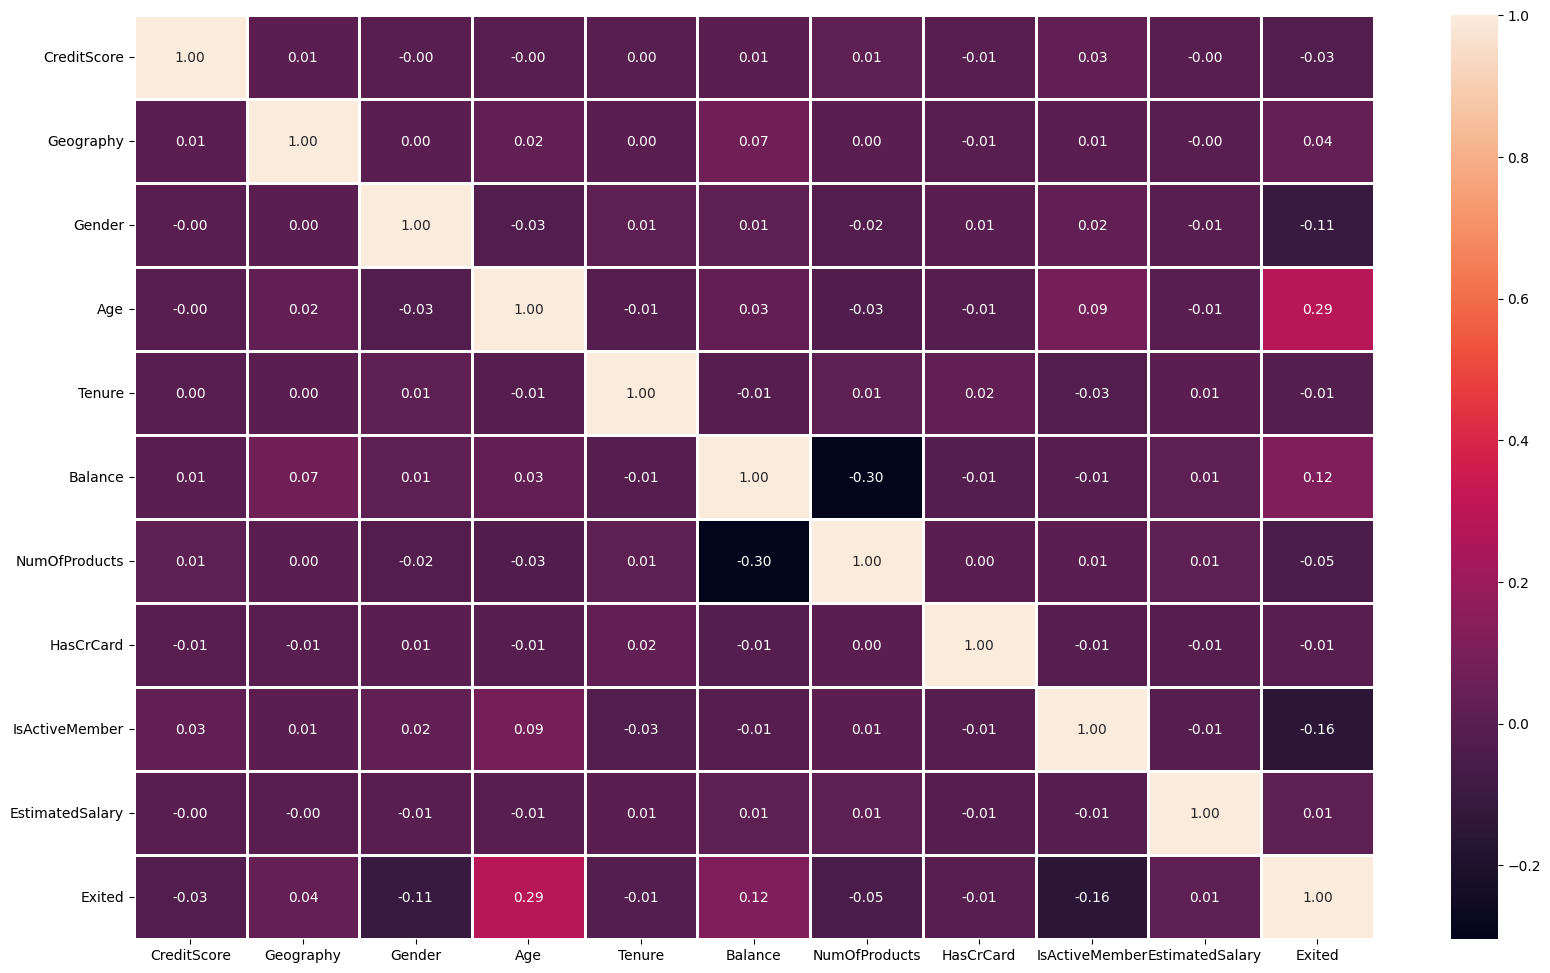

In [ ]:
plt.figure(figsize = (20, 12))

corr = df_cleaned.corr()

sns.heatmap(corr, linewidths = 1, annot = True, fmt = ".2f")
plt.show()

In [ ]:
x=df_cleaned.drop('Exited',axis=1)
y=df_cleaned['Exited']

In [ ]:
scaler=StandardScaler()
x=scaler.fit_transform(x)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42)

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=[
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc') # Evaluates imbalance far better than accuracy
    ])

In [ ]:
tf.keras.metrics.F1Score(average='micro', threshold=0.5, name='f1_score')

<F1Score name=f1_score>

In [ ]:
model_history=model.fit(x,y,validation_split = 0.20, validation_data = (X_test, y_test), epochs = 100)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4461 - pr_auc: 0.4432 - precision: 0.6847 - recall: 0.1365 - val_loss: 0.3940 - val_pr_auc: 0.5852 - val_precision: 0.7189 - val_recall: 0.3139
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3753 - pr_auc: 0.6278 - precision: 0.7429 - recall: 0.3731 - val_loss: 0.3449 - val_pr_auc: 0.6809 - val_precision: 0.7409 - val_recall: 0.4487
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3484 - pr_auc: 0.6783 - precision: 0.7548 - recall: 0.4399 - val_loss: 0.3315 - val_pr_auc: 0.6999 - val_precision: 0.7738 - val_recall: 0.4748
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3400 - pr_auc: 0.6931 - precision: 0.7659 - recall: 0.4561 - val_loss: 0.3298 - val_pr_auc: 0.7071 - val_precision: 0.8106 - val_recall: 0.4306
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3355 - pr_auc: 0.6993 - precision: 0.7651 - recall: 0.4669 - val_loss: 0.3269 - val_pr_auc: 0.7137 - val_prec

In [ ]:
# 1. Get continuous probability outputs from your sigmoid layer
val_predictions = model.predict(X_test)

# 2. Convert probabilities to hard 0 or 1 labels using your 0.5 threshold
val_preds_binary = (val_predictions > 0.5).astype(int)

# 3. Print the true report
print(classification_report(y_test, val_preds_binary))


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      2003
           1       0.82      0.73      0.77       497

    accuracy                           0.91      2500
   macro avg       0.88      0.84      0.86      2500
weighted avg       0.91      0.91      0.91      2500



In [ ]:
# Try lowering the threshold to catch more exits
for threshold in [0.5, 0.45, 0.4, 0.35]:
    preds = (model.predict(X_test) > threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print(classification_report(y_test, preds, target_names=['Stayed', 'Exited']))


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Threshold: 0.5 ---
              precision    recall  f1-score   support

      Stayed       0.93      0.96      0.95      2003
      Exited       0.82      0.73      0.77       497

    accuracy                           0.91      2500
   macro avg       0.88      0.84      0.86      2500
weighted avg       0.91      0.91      0.91      2500

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- Threshold: 0.45 ---
              precision    recall  f1-score   support

      Stayed       0.94      0.95      0.95      2003
      Exited       0.80      0.77      0.78       497

    accuracy                           0.92      2500
   macro avg       0.87      0.86      0.87      2500
weighted avg       0.91      0.92      0.92      2500

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- Threshold: 0.4 ---
              precision    recall  f1-score   support

      Stayed       0.95      0.94      0.94      2003
      Exited       0.76      0.81      0.78    

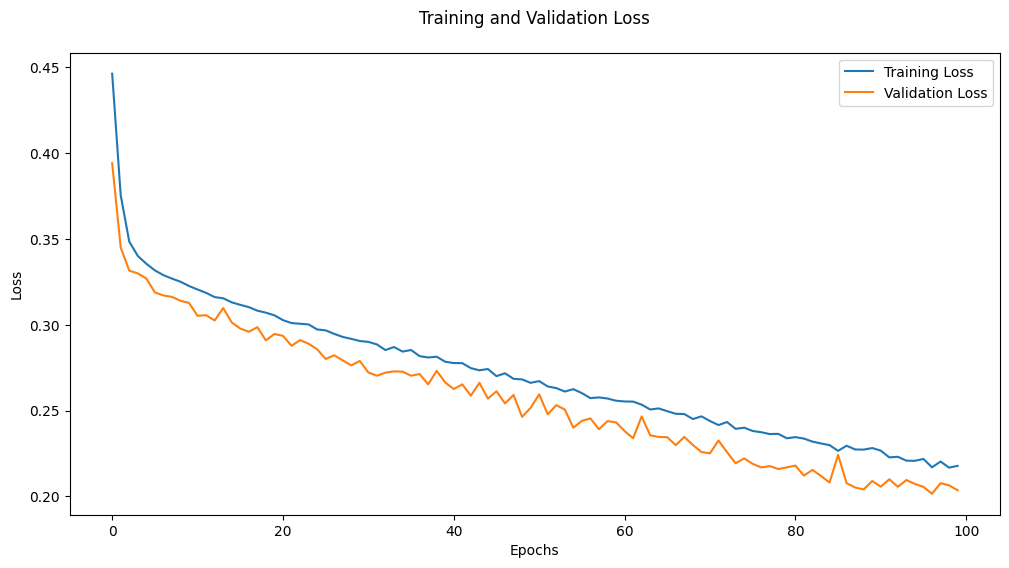

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(model_history.history['loss'], label='Training Loss')
plt.plot(model_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

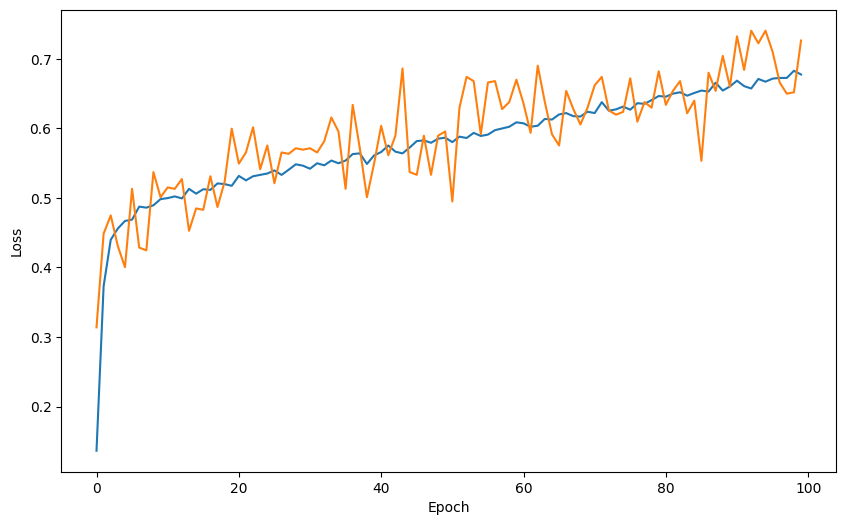

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(model_history.history['recall'], label='Training Recall')
plt.plot(model_history.history['val_recall'], label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
recall = model.evaluate(X_test, y_test)[2]

print(f'Recall of model is {recall}')

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2036 - pr_auc: 0.8844 - precision: 0.8186 - recall: 0.7264
Recall of model is 0.72635817527771


In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,989 (39.02 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,660 (26.02 KB)

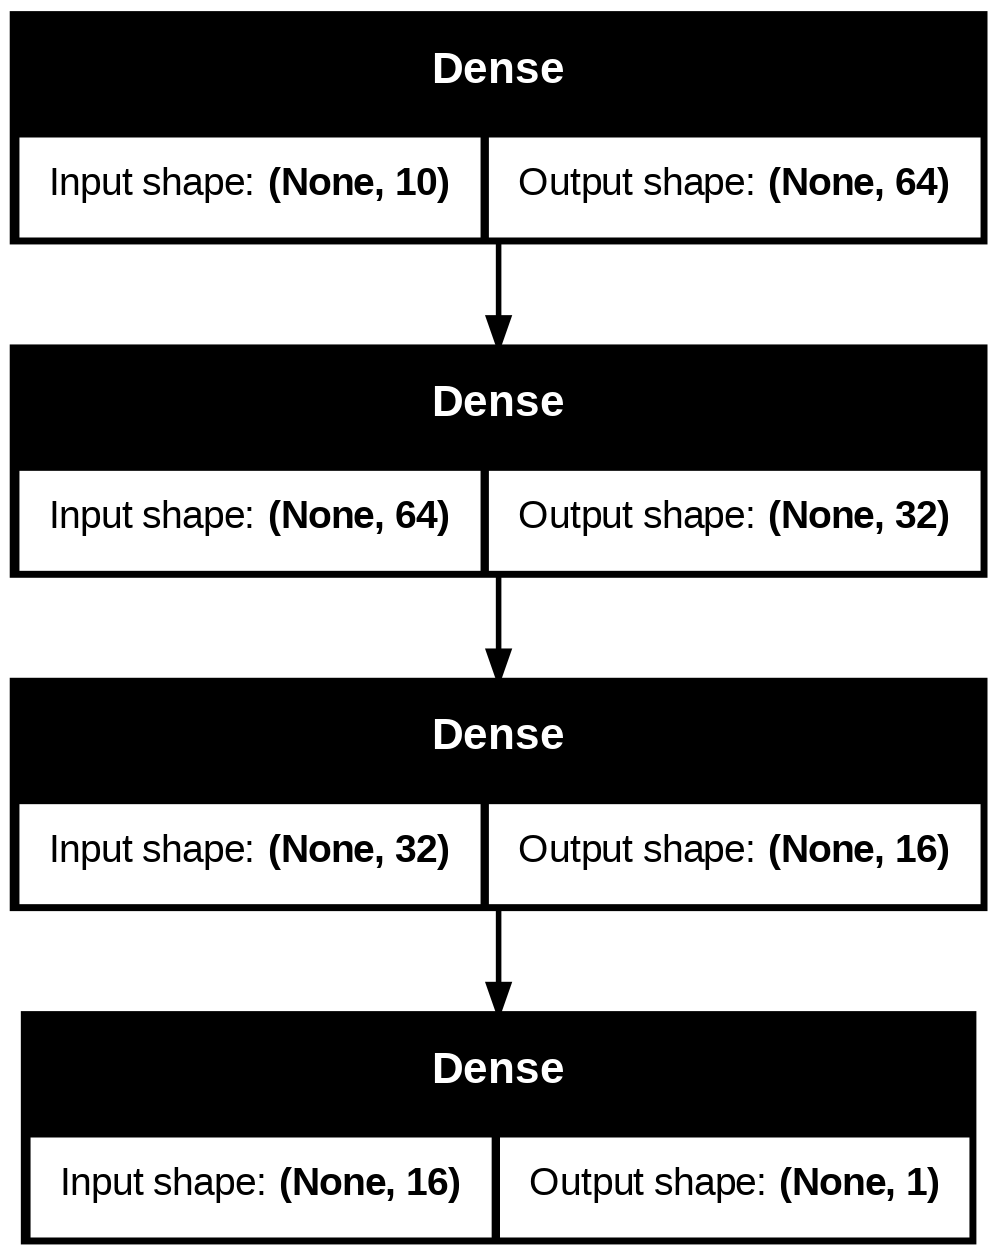

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes = True)